# ***Miniproyecto 3 - Clasificador Bayesiano***

## ***1. Importar librerías y cargar datos***

En primer lugar, se importan las slibreríass que se usarán en el trabajo.

In [1]:
import pandas as pd
import numpy as np
import math
from sklearn.pipeline import Pipeline
import missingno as msno 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

Luego, se crea un dataframe con el archivo `proceessed.cleveland.data` y el nombre de las columnas (que se encuentra en el archivo `heart-disease.names`).

In [2]:
columnas = ["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg", "thalach", "exang", "oldpeak", "slope", "ca", "thal", "num"]

df = pd.read_csv('processed.cleveland.data', header=None, names=columnas)

print(df)

      age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0    63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1    67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2    67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3    37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4    41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   
..    ...  ...  ...       ...    ...  ...      ...      ...    ...      ...   
298  45.0  1.0  1.0     110.0  264.0  0.0      0.0    132.0    0.0      1.2   
299  68.0  1.0  4.0     144.0  193.0  1.0      0.0    141.0    0.0      3.4   
300  57.0  1.0  4.0     130.0  131.0  0.0      0.0    115.0    1.0      1.2   
301  57.0  0.0  2.0     130.0  236.0  0.0      2.0    174.0    0.0      0.0   
302  38.0  1.0  3.0     138.0  175.0  0.0      0.0    173.0    0.0      0.0   

     slope   ca thal  num  
0      3.0  0.0  6.0   

## ***2. Exploración inicial de los datos***

En esta sección, se observan los datos a simple vista para conocer la base de datos en general.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    object 
 12  thal      303 non-null    object 
 13  num       303 non-null    int64  
dtypes: float64(11), int64(1), object(2)
memory usage: 33.3+ KB


Note que la base de datos cuenta con una dimensión de `303 filas` por `14 columnas`. Al parecer no hay datos faltantes.

Ahora, observemos las 5 primeras y últimas filass de la base de datos.

In [4]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [5]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
298,45.0,1.0,1.0,110.0,264.0,0.0,0.0,132.0,0.0,1.2,2.0,0.0,7.0,1
299,68.0,1.0,4.0,144.0,193.0,1.0,0.0,141.0,0.0,3.4,2.0,2.0,7.0,2
300,57.0,1.0,4.0,130.0,131.0,0.0,0.0,115.0,1.0,1.2,2.0,1.0,7.0,3
301,57.0,0.0,2.0,130.0,236.0,0.0,2.0,174.0,0.0,0.0,2.0,1.0,3.0,1
302,38.0,1.0,3.0,138.0,175.0,0.0,0.0,173.0,0.0,0.0,1.0,?,3.0,0


Podemos notar que en la última fila de la variable `ca`  presenta un registro de `?`, esto señala que posiblemente hay valores faltantes, lo que contrasta lo encontrado anteriormente.

### ***2.1. Corrección de tipos de datos***

En esta sección se convierte cada variable a el tipo más adecuado para explorar la base de datos.

Se convierten las variables categóricas que se encontraban como enteras.

In [6]:
categorical_cols = ['sex','cp','fbs','restecg','exang','slope','ca','thal', 'num']
for col in categorical_cols:
    df[col] = df[col].astype('category')

Se verifican valores faltantes y categorías de cada variable cualitativa.

In [7]:
print(df.isnull().sum())
for col in df.columns:
    if df[col].dtype == 'category':
        print(col, df[col].unique())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64
sex [1.0, 0.0]
Categories (2, float64): [0.0, 1.0]
cp [1.0, 4.0, 3.0, 2.0]
Categories (4, float64): [1.0, 2.0, 3.0, 4.0]
fbs [1.0, 0.0]
Categories (2, float64): [0.0, 1.0]
restecg [2.0, 0.0, 1.0]
Categories (3, float64): [0.0, 1.0, 2.0]
exang [0.0, 1.0]
Categories (2, float64): [0.0, 1.0]
slope [3.0, 2.0, 1.0]
Categories (3, float64): [1.0, 2.0, 3.0]
ca ['0.0', '3.0', '2.0', '1.0', '?']
Categories (5, object): ['0.0', '1.0', '2.0', '3.0', '?']
thal ['6.0', '3.0', '7.0', '?']
Categories (4, object): ['3.0', '6.0', '7.0', '?']
num [0, 2, 1, 3, 4]
Categories (5, int64): [0, 1, 2, 3, 4]


Note que la variable target `num` cuenta con 5 categorías, pero en este trabajo solo se clasificaráa por ausencia o no de la enfermedad, por lo que debemos correguir las categorías.

In [8]:
df["num"] = df["num"].astype('int')

In [9]:
# Variable objetivo: num → binaria (0 = sano, 1 = enfermedad)
df['num'] = (df['num'] > 0).astype(int)

In [10]:
df['num'].unique()

array([0, 1])

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   age       303 non-null    float64 
 1   sex       303 non-null    category
 2   cp        303 non-null    category
 3   trestbps  303 non-null    float64 
 4   chol      303 non-null    float64 
 5   fbs       303 non-null    category
 6   restecg   303 non-null    category
 7   thalach   303 non-null    float64 
 8   exang     303 non-null    category
 9   oldpeak   303 non-null    float64 
 10  slope     303 non-null    category
 11  ca        303 non-null    category
 12  thal      303 non-null    category
 13  num       303 non-null    int64   
dtypes: category(8), float64(5), int64(1)
memory usage: 17.9 KB


In [12]:
df['num'] = df['num'].astype('category')

## ***3. Identificación y tratamiento de valores faltantes***

Debido a lo encontrado, se hará una correcta detección y tratamiento de valores faltantes.


En primer lugar, se convierten los datos `?` a `NaN`para luego poder indentificarlos y tratarlos.

In [13]:
df['ca'] = pd.to_numeric(df['ca'], errors='coerce').astype('category')   
df['thal'] = pd.to_numeric(df['thal'], errors='coerce').astype('category') 

Observemos el mapa de calor y tabla de valores faltantes sin modificar la base de datos.

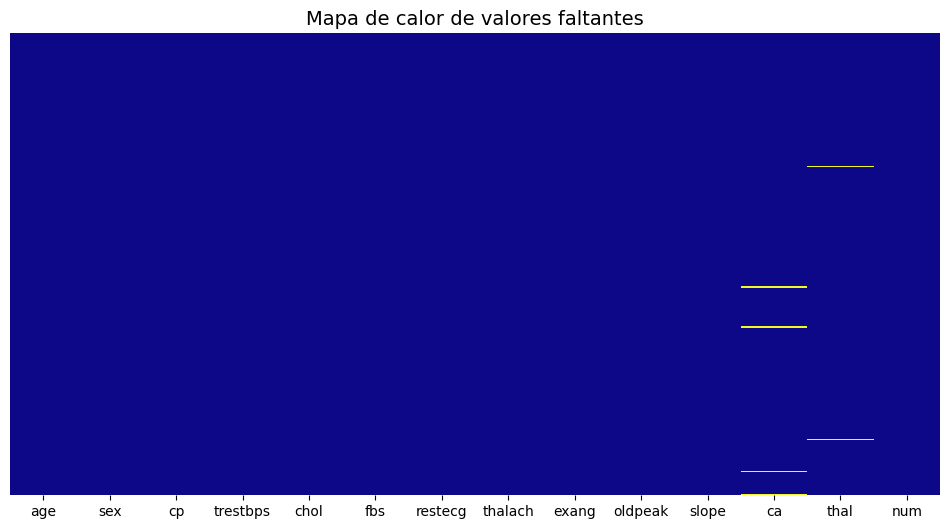

In [14]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='plasma')
plt.title("Mapa de calor de valores faltantes", fontsize=14)
plt.show()

In [15]:
faltantes = df.isnull().sum()
porcentaje = (faltantes / len(df)) * 100

tabla_faltantes = pd.DataFrame({
    'Valores faltantes': faltantes,
    'Porcentaje (%)': porcentaje
})

# Mostrar solo columnas con NA
tabla_faltantes = tabla_faltantes[tabla_faltantes['Valores faltantes'] > 0]
tabla_faltantes.sort_values('Porcentaje (%)', ascending=False)

,Valores faltantes,Porcentaje (%)
ca,4,1.320132
thal,2,0.660066


Se identifican solamente 6 datos faltantes, por lo que se pueden tratar con métodos simples de imputación. Como estas variables se clasifican como categóricas, se procede a imputar por la moda.

Primero observemos como se encuentran dsitribuidas las categorías de cada variable.

In [16]:
def resumen_categorias(df, columna):
    conteo = df[columna].value_counts(dropna=False)
    porcentaje = (conteo / len(df)) * 100

    tabla = pd.DataFrame({
        'Conteo': conteo,
        'Porcentaje (%)': porcentaje.round(2)
    })

    return tabla

In [17]:
resumen_categorias(df,"ca")

,Conteo,Porcentaje (%)
ca,,
0.0,176,58.09
1.0,65,21.45
2.0,38,12.54
3.0,20,6.60
NaN,4,1.32


In [18]:
resumen_categorias(df,"thal")

,Conteo,Porcentaje (%)
thal,,
3.0,166,54.79
7.0,117,38.61
6.0,18,5.94
NaN,2,0.66


Note que efectivamente las datos faltantes en ambas variables equivalen a un porcentaje bajo en lo que respecta al resto de categorías.

In [19]:
def imputar_por_moda(df, df_copy, columnas):
    for col in columnas:
        moda = df_copy[col].mode()
        if not moda.empty:
            df_copy[col].fillna(moda[0], inplace=True)
        else:
            print(f"Advertencia: La columna {col} está vacía o no tiene moda.")
    return df_copy

In [20]:
df_imputado = df.copy()
datos_imputados = imputar_por_moda(df, df_imputado, ['ca','thal'])

C:\Users\maria\AppData\Local\Temp\ipykernel_22932\3086753634.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_copy[col].fillna(moda[0], inplace=True)


In [21]:
def comparar_categoricas(df_original, df, columnas):

    for col in columnas:
        plt.figure(figsize=(14,5))
        
        plt.subplot(1, 2, 1)
        sns.countplot(y=df_original[col], order=df_original[col].value_counts().index)
        plt.title(f"{col} - Original (con NA)")
        
        plt.subplot(1, 2, 2)
        sns.countplot(y=df[col], order=df[col].value_counts().index)
        plt.title(f"{col} - Después de imputar")
        
        plt.tight_layout()
        plt.show()

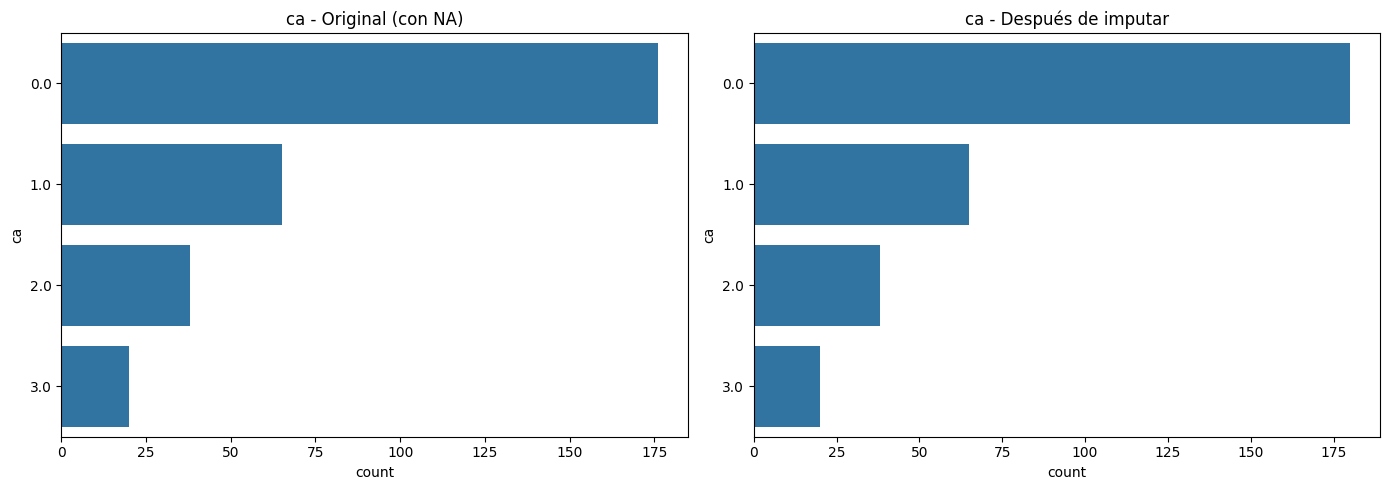

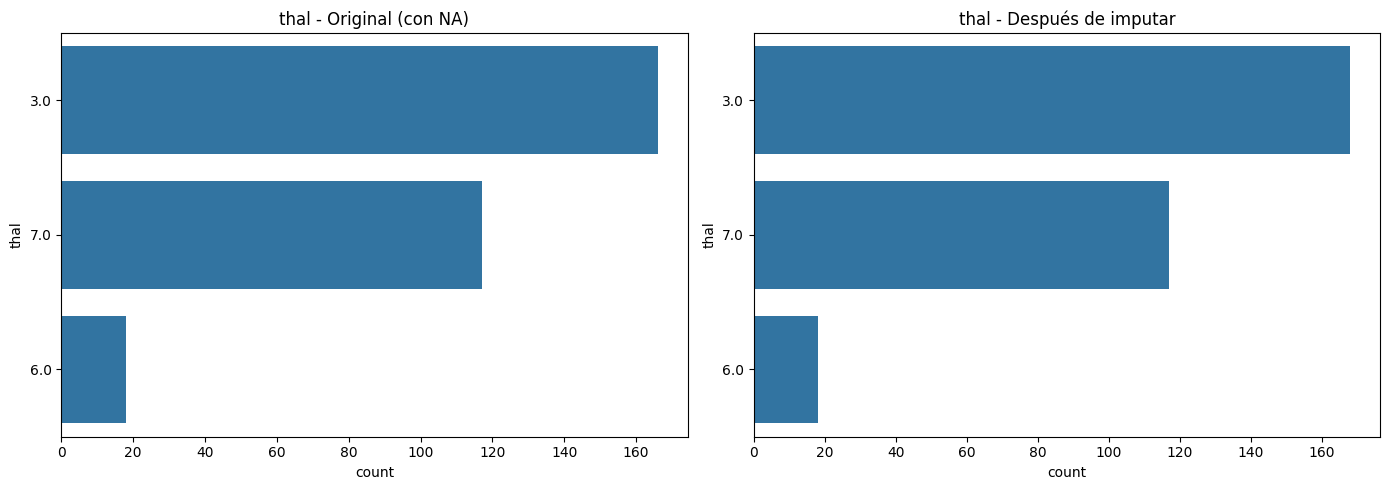

In [22]:
comparar_categoricas(df, df_imputado, ['ca', 'thal'])

Efectivamente las distribuciones de ambas variables mantuvieron las proporciones originales.

In [23]:
df = df_imputado

## ***4. Análisis exploratorio de los datos***

A continuación, tenemos algunas funciones que se utilizarán en esta sección.

In [24]:
def graficar_cat(n_cols, cat, figura_num=1, titulo_general=None, palette='Set2'):
    # Número de columnas fijas
    cols = 3
    rows = math.ceil(n_cols / cols)

    # Crear figura
    fig, axs = plt.subplots(rows, cols, figsize=(cols*6, rows*4))
    axs = axs.flatten()

    for i, col in enumerate(cat):
        ax = axs[i]
        n_cat = df[col].nunique()

        if n_cat <= 10:
            orden = df[col].value_counts().sort_values(ascending=False).index
            sns.countplot(x=col, data=df, order=orden, ax=ax, palette=palette)
        else:
            top_10 = df[col].value_counts().nlargest(10)
            categorias_ordenadas = top_10.index
            frecuencias = top_10.values
            sns.barplot(x=categorias_ordenadas, y=frecuencias, ax=ax, palette=palette)

        ax.set_title(f'{col} ({n_cat} cat.)', fontsize=10)
        ax.set_xlabel('')
        ax.set_ylabel('Frecuencia')
        ax.tick_params(axis='x', rotation=45)

    # Eliminar ejes vacíos
    for j in range(i + 1, len(axs)):
        fig.delaxes(axs[j])

    # Ajustar el espacio automáticamente
    plt.tight_layout(rect=[0, 0.05, 1, 0.93])  # deja espacio para el título y el pie

    # Título general centrado
    if titulo_general:
        fig.text(0.5, 0.96, titulo_general, ha='center', fontsize=16, weight='bold')

    # Pie de figura centrado
    fig.text(0.5, 0.02, f'Figura {figura_num}. {titulo_general}', ha='center', fontsize=12)
    

    plt.show()

In [25]:
def resumen_categorias(df, columna):
    conteo = df[columna].value_counts(dropna=False)
    porcentaje = (conteo / len(df)) * 100

    tabla = pd.DataFrame({
        'Conteo': conteo,
        'Porcentaje (%)': porcentaje.round(2)
    })

    return tabla

### ***4.1. Variables numéricas***

In [26]:
df.describe()

,age,trestbps,chol,thalach,oldpeak
count,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,131.689769,246.693069,149.607261,1.039604
std,9.038662,17.599748,51.776918,22.875003,1.161075
min,29.000000,94.000000,126.000000,71.000000,0.000000
25%,48.000000,120.000000,211.000000,133.500000,0.000000
50%,56.000000,130.000000,241.000000,153.000000,0.800000
75%,61.000000,140.000000,275.000000,166.000000,1.600000
max,77.000000,200.000000,564.000000,202.000000,6.200000


**`age`:**  La edad promedio de los pacientes es de aproximadamente 54 años con una desviación estánda de 9.04. Las edades van desde los 29 años a los 77 años con una mediana de 56 años, lo que nos indica que estamos ante una población de adultos de mediana edad a mayores.

**`trestbps`:** La presión arterial en reposo tiene un promedio de 131.69 mmHg con desviación estandar de 17.60. La mediana es de 130  y los valores están entre 94 y 200, indicando una distribución relativamente centrada sin grandes desviaciones respecto a la media.

**`chol`:** El colesterol alcanza un promedio de 246.69 con desviación estandar de 51.78. La mediana es 241 y el rango va de 126 a 564, lo que sugiere alta variabilidad y presencia de valores atípicos altos.

**`Thalach`:** La frecuencia cardíaca máxima alcanzada muestra un promedio de 149.61 con desviación estandar de 22.87. La mediana es 153 y los valores van de 71 a 202, con ligera asímetria hacia valores bajos.

**`Oldpeak`:** Presenta un promedio de 1.04 con desviación estandar de 1.16. La mediana es 0.8 y los valores oscilan entre 0 y 6.2.

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

def graficar_histograma_y_boxplot(df, columna, bins=50, color='steelblue', figsize=(12, 5)):

    if columna not in df.columns:
        raise ValueError(f"La columna '{columna}' no está en el DataFrame.")

    if not pd.api.types.is_numeric_dtype(df[columna]):
        raise TypeError(f"La columna '{columna}' no es numérica.")

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # Histograma
    axes[0].hist(df[columna].dropna(), bins=bins, color=color, edgecolor='black')
    axes[0].set_xlabel(columna)
    axes[0].set_ylabel("Frecuencia")
    axes[0].set_title(f"Distribución de {columna}")

    # Boxplot
    sns.boxplot(y=df[columna], ax=axes[1], color=color)
    axes[1].set_title(f"Boxplot de {columna}")
    axes[1].set_ylabel(columna)

    plt.tight_layout()
    plt.show()


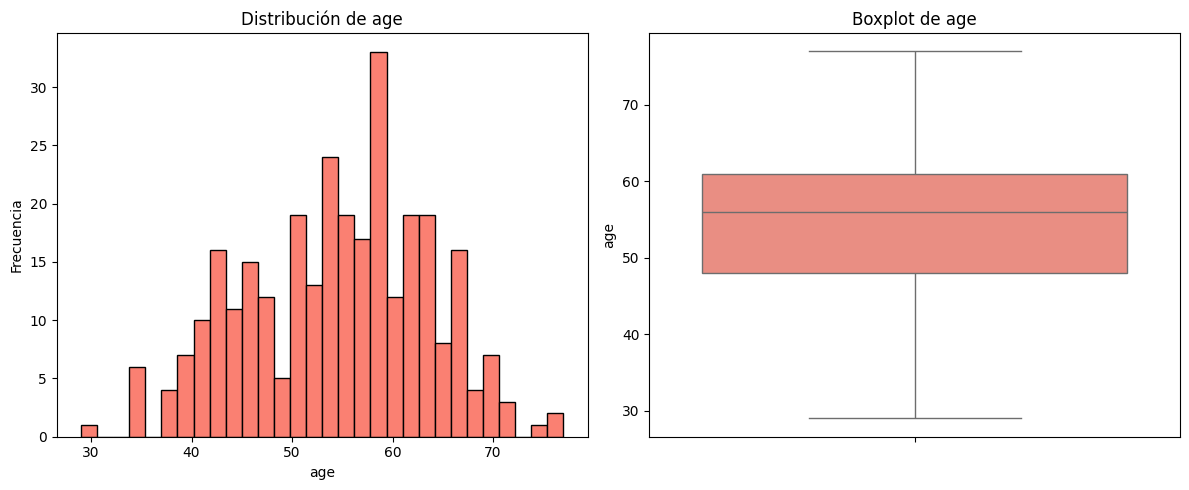

In [28]:
graficar_histograma_y_boxplot(df, "age", bins=30, color='salmon')

La distribución revela un patron aproximadamente simétrico, tambien podemos observar que la edad de la mayoría de los individuos se concentran entre los 45 y 65 años, con una mediana cercana a los 56 años. El boxplot indica que el 50% de los datos se ubican entre 48 y 61 años. Los valores extremos alcanzan desde 29 hasta 77, sin presencia marcada de outliers.

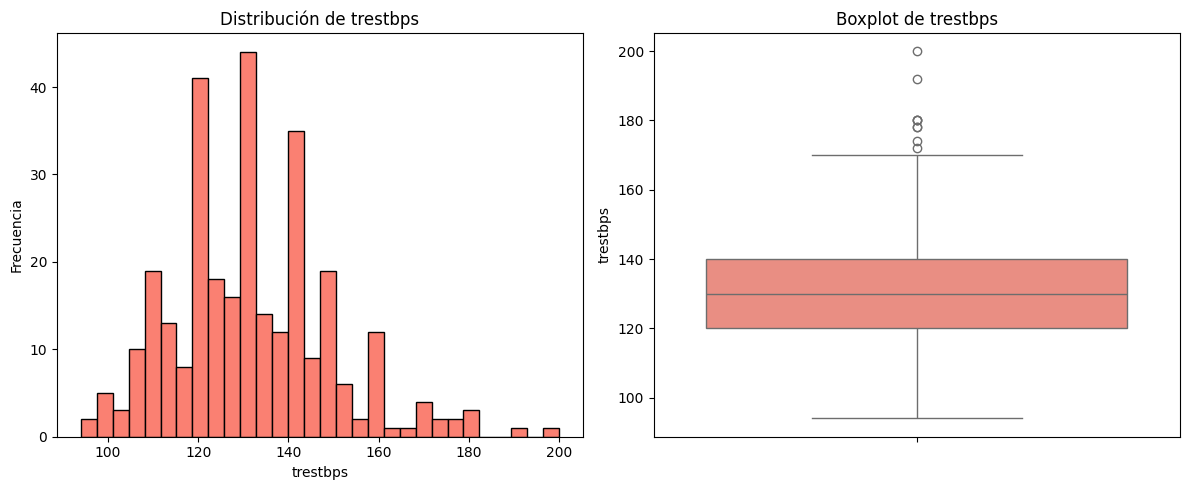

In [29]:
graficar_histograma_y_boxplot(df, "trestbps", bins=30, color='salmon')

La variable trestbps (presión arterial en reposo) presenta una distribución concentrada principalmente entre 110 y 150 mmHg, con una mediana cercana a 130 mmHg. El histograma muestra una forma relativamente simétrica con mayor frecuencia alrededor de los valores centrales, mientras que el boxplot confirma que el 50% de los datos se ubican entre aproximadamente 120 y 140 mmHg. Se observan algunos valores atípicos que superan los 170 mmHg, alcanzando un máximo cercano a 200 mmHg, lo que indica la presencia de casos con presión arterial significativamente elevada respecto al resto de la población.

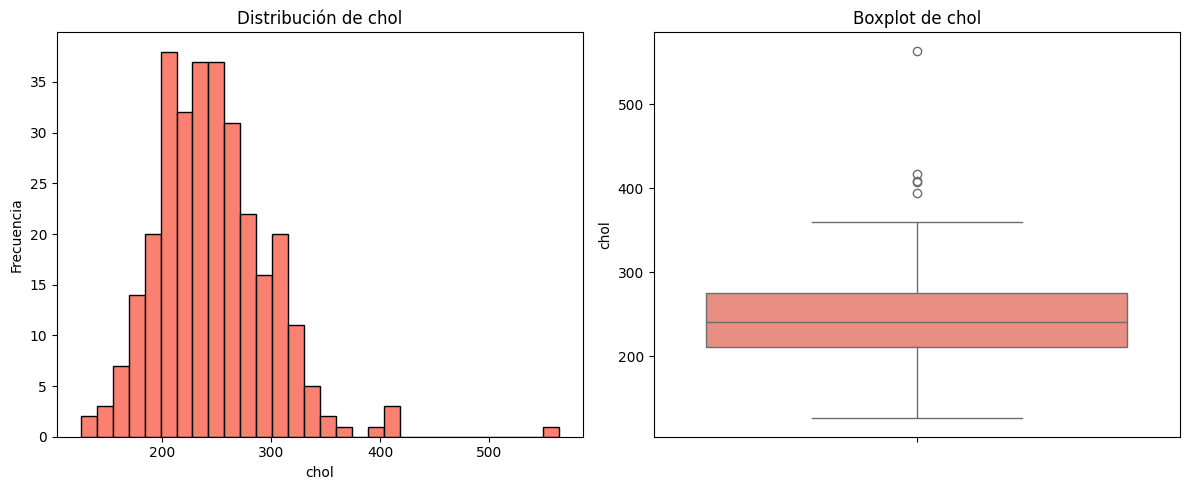

In [30]:
graficar_histograma_y_boxplot(df, "chol", bins=30, color='salmon')

La variable chol (colesterol sérico) presenta una distribución con mayor concentración entre 200 y 280 mg/dl, con una mediana cercana a 241 mg/dl. El histograma muestra una ligera asimetría hacia la derecha, reflejada en la presencia de valores más elevados aunque menos frecuentes. El boxplot confirma que la mayoría de los datos se sitúan en un rango intercuartílico de aproximadamente 210 a 275 mg/dl, mientras que se observan valores atípicos que superan los 400 mg/dl y alcanzan un máximo superior a 550 mg/dl.

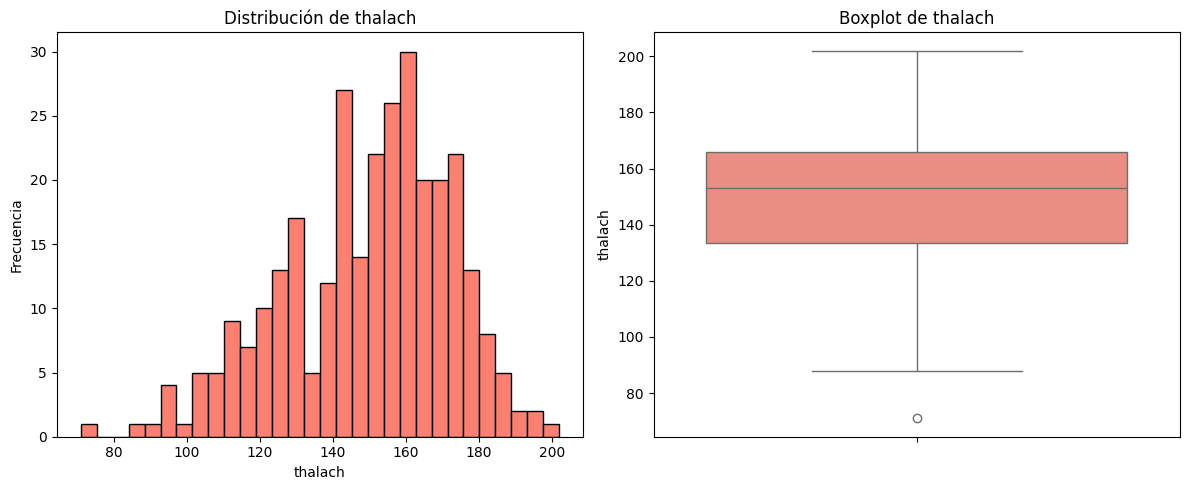

In [31]:
graficar_histograma_y_boxplot(df, "thalach", bins=30, color='salmon')

La variable thalach (frecuencia cardíaca máxima alcanzada) muestra una distribución centrada principalmente entre 140 y 170 latidos por minuto, con una mediana cercana a 153 lpm. El histograma refleja una ligera asimetria hacia la izquierda, mientras que el boxplot evidencia que el 50% de los datos se sitúan en un rango intercuartilico entre 134 y 166 lpm. Los valores mínimos alcanzan alrededor de 70 lpm y el máximo supera los 200 lpm. Se observa un valor atípico en el extremo inferior, correspondiente a una frecuencia considerablemente baja.

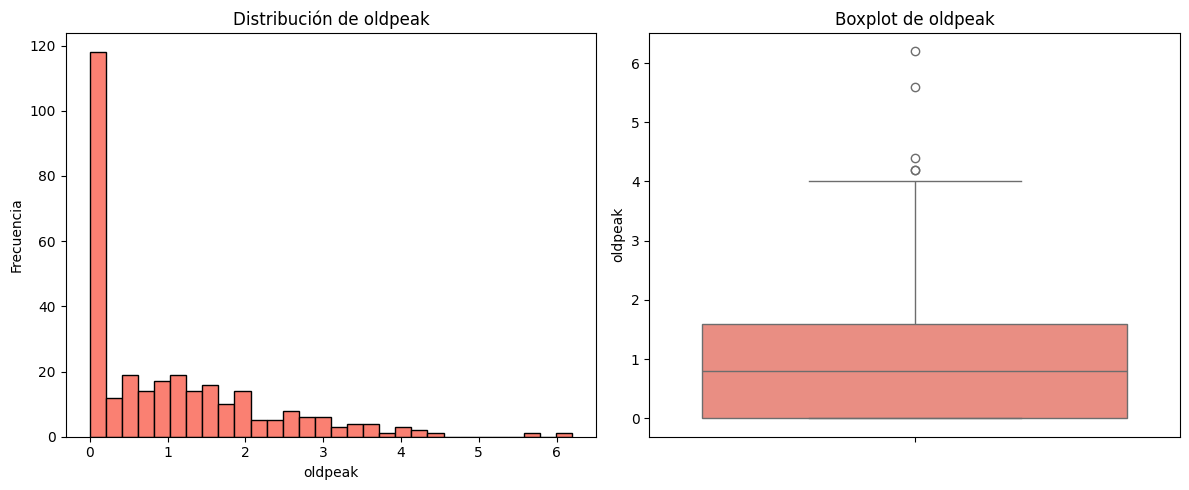

In [32]:
graficar_histograma_y_boxplot(df, "oldpeak", bins=30, color='salmon')

La variable oldpeak (depresión del segmento ST inducida por ejercicio) presenta una distribución fuertemente asimétrica a la derecha, con la mayoría de los valores concentrados en torno a 0 y 1. El histograma evidencia que gran parte de los individuos no presentan depresión significativa, mientras que el boxplot muestra que el 50% de los datos se ubican entre 0 y aproximadamente 1.6, con una mediana cercana a 0.8. Se identifican varios valores atípicos que superan los 4, alcanzando un máximo de 6.2, lo que indica la existencia de casos con niveles de depresión del ST considerablemente elevados en comparación con el resto de la población.

### ***4.2. Variables categóricas***

In [33]:
df.describe(include='category')

,sex,cp,fbs,restecg,exang,slope,ca,thal,num
count,303.0,303.0,303.0,303.0,303.0,303.0,303.0,303.0,303
unique,2.0,4.0,2.0,3.0,2.0,3.0,4.0,3.0,2
top,1.0,4.0,0.0,0.0,0.0,1.0,0.0,3.0,0
freq,206.0,144.0,258.0,151.0,204.0,142.0,180.0,168.0,164


**`sex`:** La mayoría de los participantes son hombres (206), mientras que las mujeres representan una proporción menor (97), lo que evidencia un predominio masculino en la muestra.

**`Cp`:** predomina la categoría 4 con 144 observaciones, lo que sugiere que más de un tercio de la población presenta este tipo específico de dolor, mientras que las demás categorías tienen menor representación.

**`Fbs`:** la gran mayoría de los individuos (258) no superan el umbral de 120 mg/dl, mientras que solo 45 lo hacen, lo que refleja una baja prevalencia de glucemia elevada en la muestra.

**`Restecg`:** la categoría más frecuente es la 0 con 151 observaciones, seguida de las categorías 1 y 2 en menor proporción, lo que indica predominio de un resultado considerado normal o sin alteraciones destacadas.

**`Exang`:** 204 sujetos no presentan angina tras el ejercicio, en contraste con 99 que sí la manifiestan, lo que sugiere que la mayoría de los participantes no desarrolla este síntoma en pruebas de esfuerzo.

**`Slope`:** la categoría predominante es la 1 con 142 observaciones, mientras que las categorías restantes muestran menor frecuencia, indicando una distribución concentrada en un patrón específico de respuesta cardíaca al ejercicio.

**`Ca`:** la mayoría presenta un valor de 0 (180 casos), lo que indica ausencia de vasos coloreados en gran parte de la muestra, aunque existen pacientes con valores de 1 a 3.

**`Thal`:** la categoría más frecuente es la 3 con 168 casos, mientras que las demás categorías se presentan en menor medida, lo que muestra una fuerte concentración en un valor específico.

**`Num`:** 164 individuos no presentan la enfermedad, frente a 139 que sí la presentan, lo que evidencia una distribución relativamente equilibrada entre casos positivos y negativos.

In [34]:
resumen_categorias(df, "sex")

,Conteo,Porcentaje (%)
sex,,
1.0,206,67.99
0.0,97,32.01


In [35]:
resumen_categorias(df, "cp")

,Conteo,Porcentaje (%)
cp,,
4.0,144,47.52
3.0,86,28.38
2.0,50,16.50
1.0,23,7.59


In [36]:
resumen_categorias(df, "fbs")

,Conteo,Porcentaje (%)
fbs,,
0.0,258,85.15
1.0,45,14.85


In [37]:
resumen_categorias(df, "restecg")

,Conteo,Porcentaje (%)
restecg,,
0.0,151,49.83
2.0,148,48.84
1.0,4,1.32


In [38]:
resumen_categorias(df, "exang")

,Conteo,Porcentaje (%)
exang,,
0.0,204,67.33
1.0,99,32.67


In [39]:
resumen_categorias(df, "slope")

,Conteo,Porcentaje (%)
slope,,
1.0,142,46.86
2.0,140,46.20
3.0,21,6.93


In [40]:
resumen_categorias(df, "ca")

,Conteo,Porcentaje (%)
ca,,
0.0,180,59.41
1.0,65,21.45
2.0,38,12.54
3.0,20,6.60


In [41]:
resumen_categorias(df, "thal")

,Conteo,Porcentaje (%)
thal,,
3.0,168,55.45
7.0,117,38.61
6.0,18,5.94


In [42]:
resumen_categorias(df, "num")

,Conteo,Porcentaje (%)
num,,
0,164,54.13
1,139,45.87


In [43]:
def graficar_cat(n_cols, cat, figura_num=1, titulo_general=None, palette='Set2'):
    import math
    import matplotlib.pyplot as plt
    import seaborn as sns

    # Número de columnas fijas
    cols = 3
    rows = math.ceil(n_cols / cols)

    # Crear figura
    fig, axs = plt.subplots(rows, cols, figsize=(cols*6, rows*4))
    axs = axs.flatten()

    for i, col in enumerate(cat):
        ax = axs[i]
        n_cat = df[col].nunique()

        if n_cat <= 10:
            orden = df[col].value_counts().sort_values(ascending=False).index
            sns.countplot(x=col, data=df, order=orden, ax=ax, palette=palette)
        else:
            top_10 = df[col].value_counts().nlargest(10)
            categorias_ordenadas = top_10.index
            frecuencias = top_10.values
            sns.barplot(x=categorias_ordenadas, y=frecuencias, ax=ax, palette=palette)

        ax.set_title(f'{col} ({n_cat} cat.)', fontsize=10)
        ax.set_xlabel('')
        ax.set_ylabel('Frecuencia')
        ax.tick_params(axis='x', rotation=45)

    # Eliminar ejes vacíos
    for j in range(i + 1, len(axs)):
        fig.delaxes(axs[j])

    # Ajustar el espacio automáticamente
    plt.tight_layout(rect=[0, 0.05, 1, 0.93])  # deja espacio para el título y el pie

    # Título general centrado
    if titulo_general:
        fig.text(0.5, 0.96, titulo_general, ha='center', fontsize=16, weight='bold')

    # Pie de figura centrado
    fig.text(0.5, 0.02, f'Figura {figura_num}. {titulo_general}', ha='center', fontsize=12)
    

    plt.show()


C:\Users\maria\AppData\Local\Temp\ipykernel_22932\2055399804.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, order=orden, ax=ax, palette=palette)
C:\Users\maria\AppData\Local\Temp\ipykernel_22932\2055399804.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, order=orden, ax=ax, palette=palette)
C:\Users\maria\AppData\Local\Temp\ipykernel_22932\2055399804.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, order=orden, ax=ax, palette=palette)
C:\Users\maria\AppData\Local\Temp\ipyker

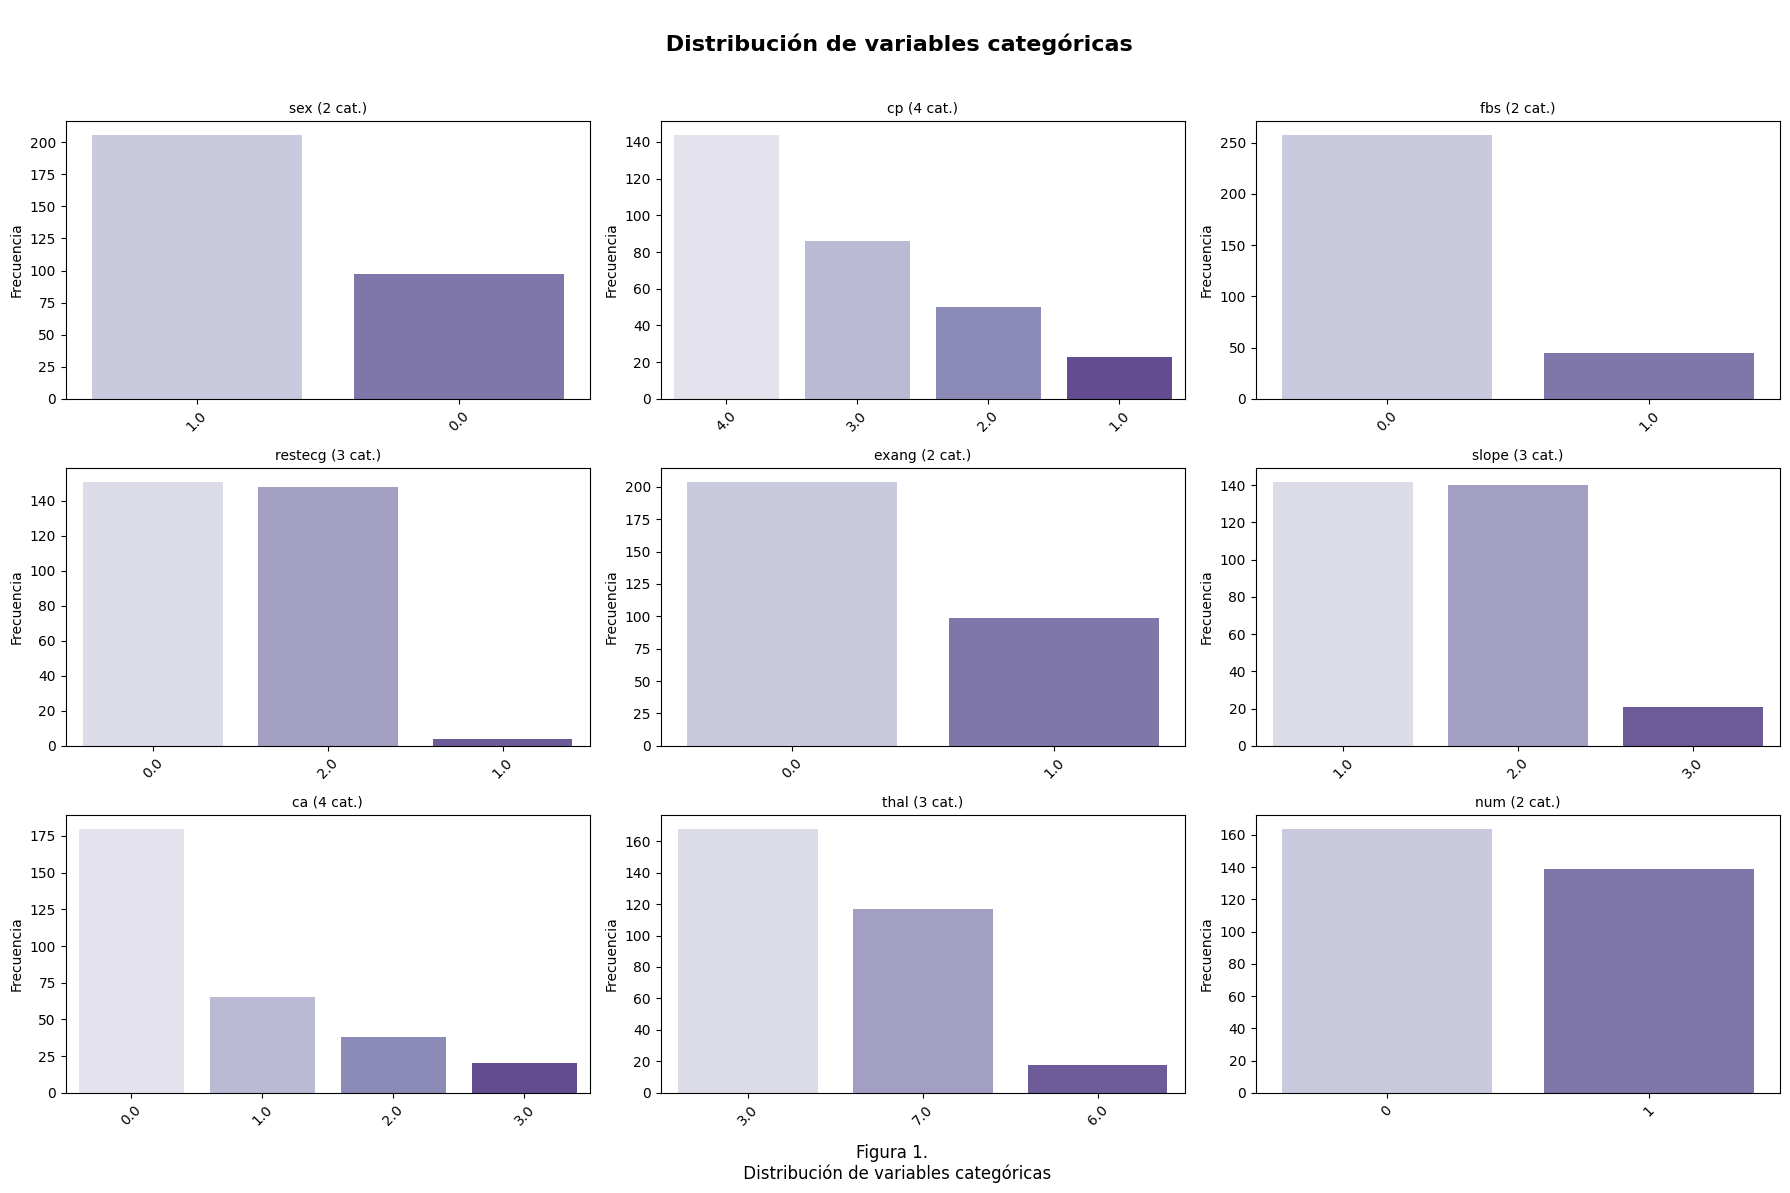

In [44]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns

graficar_cat(len(cat_cols), cat_cols, figura_num=1,
             titulo_general='\n Distribución de variables categóricas',
             palette='Purples') 

La figura muestra que la mayoría de los registros pertenecen a hombres (*sex*), con predominancia clara de una categoría. En *cp* (tipo de dolor torácico), una sola categoría domina, lo que sugiere un patrón clínico común. La variable *fbs* indica que la mayoría tiene glucemia en ayunas normal. En *restecg*, dos tipos de resultados de electrocardiograma son frecuentes, mientras que uno es raro. La variable *exang* revela que la mayoría no presenta angina inducida por ejercicio. En *slope*, una pendiente del segmento ST es claramente más común. Finalmente, *num*, que parece ser la variable objetivo, muestra una ligera desproporción entre clases, lo que podría influir en el análisis predictivo.

In [45]:
def plot_relationships_matrix(df, target_var):
    cols = [col for col in df.columns if col != target_var]
    n = len(cols)

    # Definir número de filas y columnas de la matriz
    n_cols = 3  # puedes ajustar este valor
    n_rows = int(np.ceil(n / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*6, n_rows*5))
    axes = axes.flatten()

    for i, col in enumerate(cols):
        ax = axes[i]

        if pd.api.types.is_numeric_dtype(df[col]):
            sns.boxplot(x=target_var, y=col, data=df, ax=ax)
            ax.set_title(f'Distribución de {col} por {target_var}')
        
        elif pd.api.types.is_categorical_dtype(df[col]) or pd.api.types.is_object_dtype(df[col]):
            sns.countplot(x=col, hue=target_var, data=df, ax=ax)
            ax.set_title(f'Frecuencia de {col} segmentada por {target_var}')
            ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

    # Eliminar ejes vacíos si sobran
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

C:\Users\maria\AppData\Local\Temp\ipykernel_22932\1030035781.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(df[col]) or pd.api.types.is_object_dtype(df[col]):
C:\Users\maria\AppData\Local\Temp\ipykernel_22932\1030035781.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
C:\Users\maria\AppData\Local\Temp\ipykernel_22932\1030035781.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(df[col]) or pd.api.types.is_object_dtype(df[col]):
C:\Users\maria\AppData\Local\Temp\ipykernel_22932\1030035781.py:22: UserWarning: set_ticklabels() should only be used with a fixed num

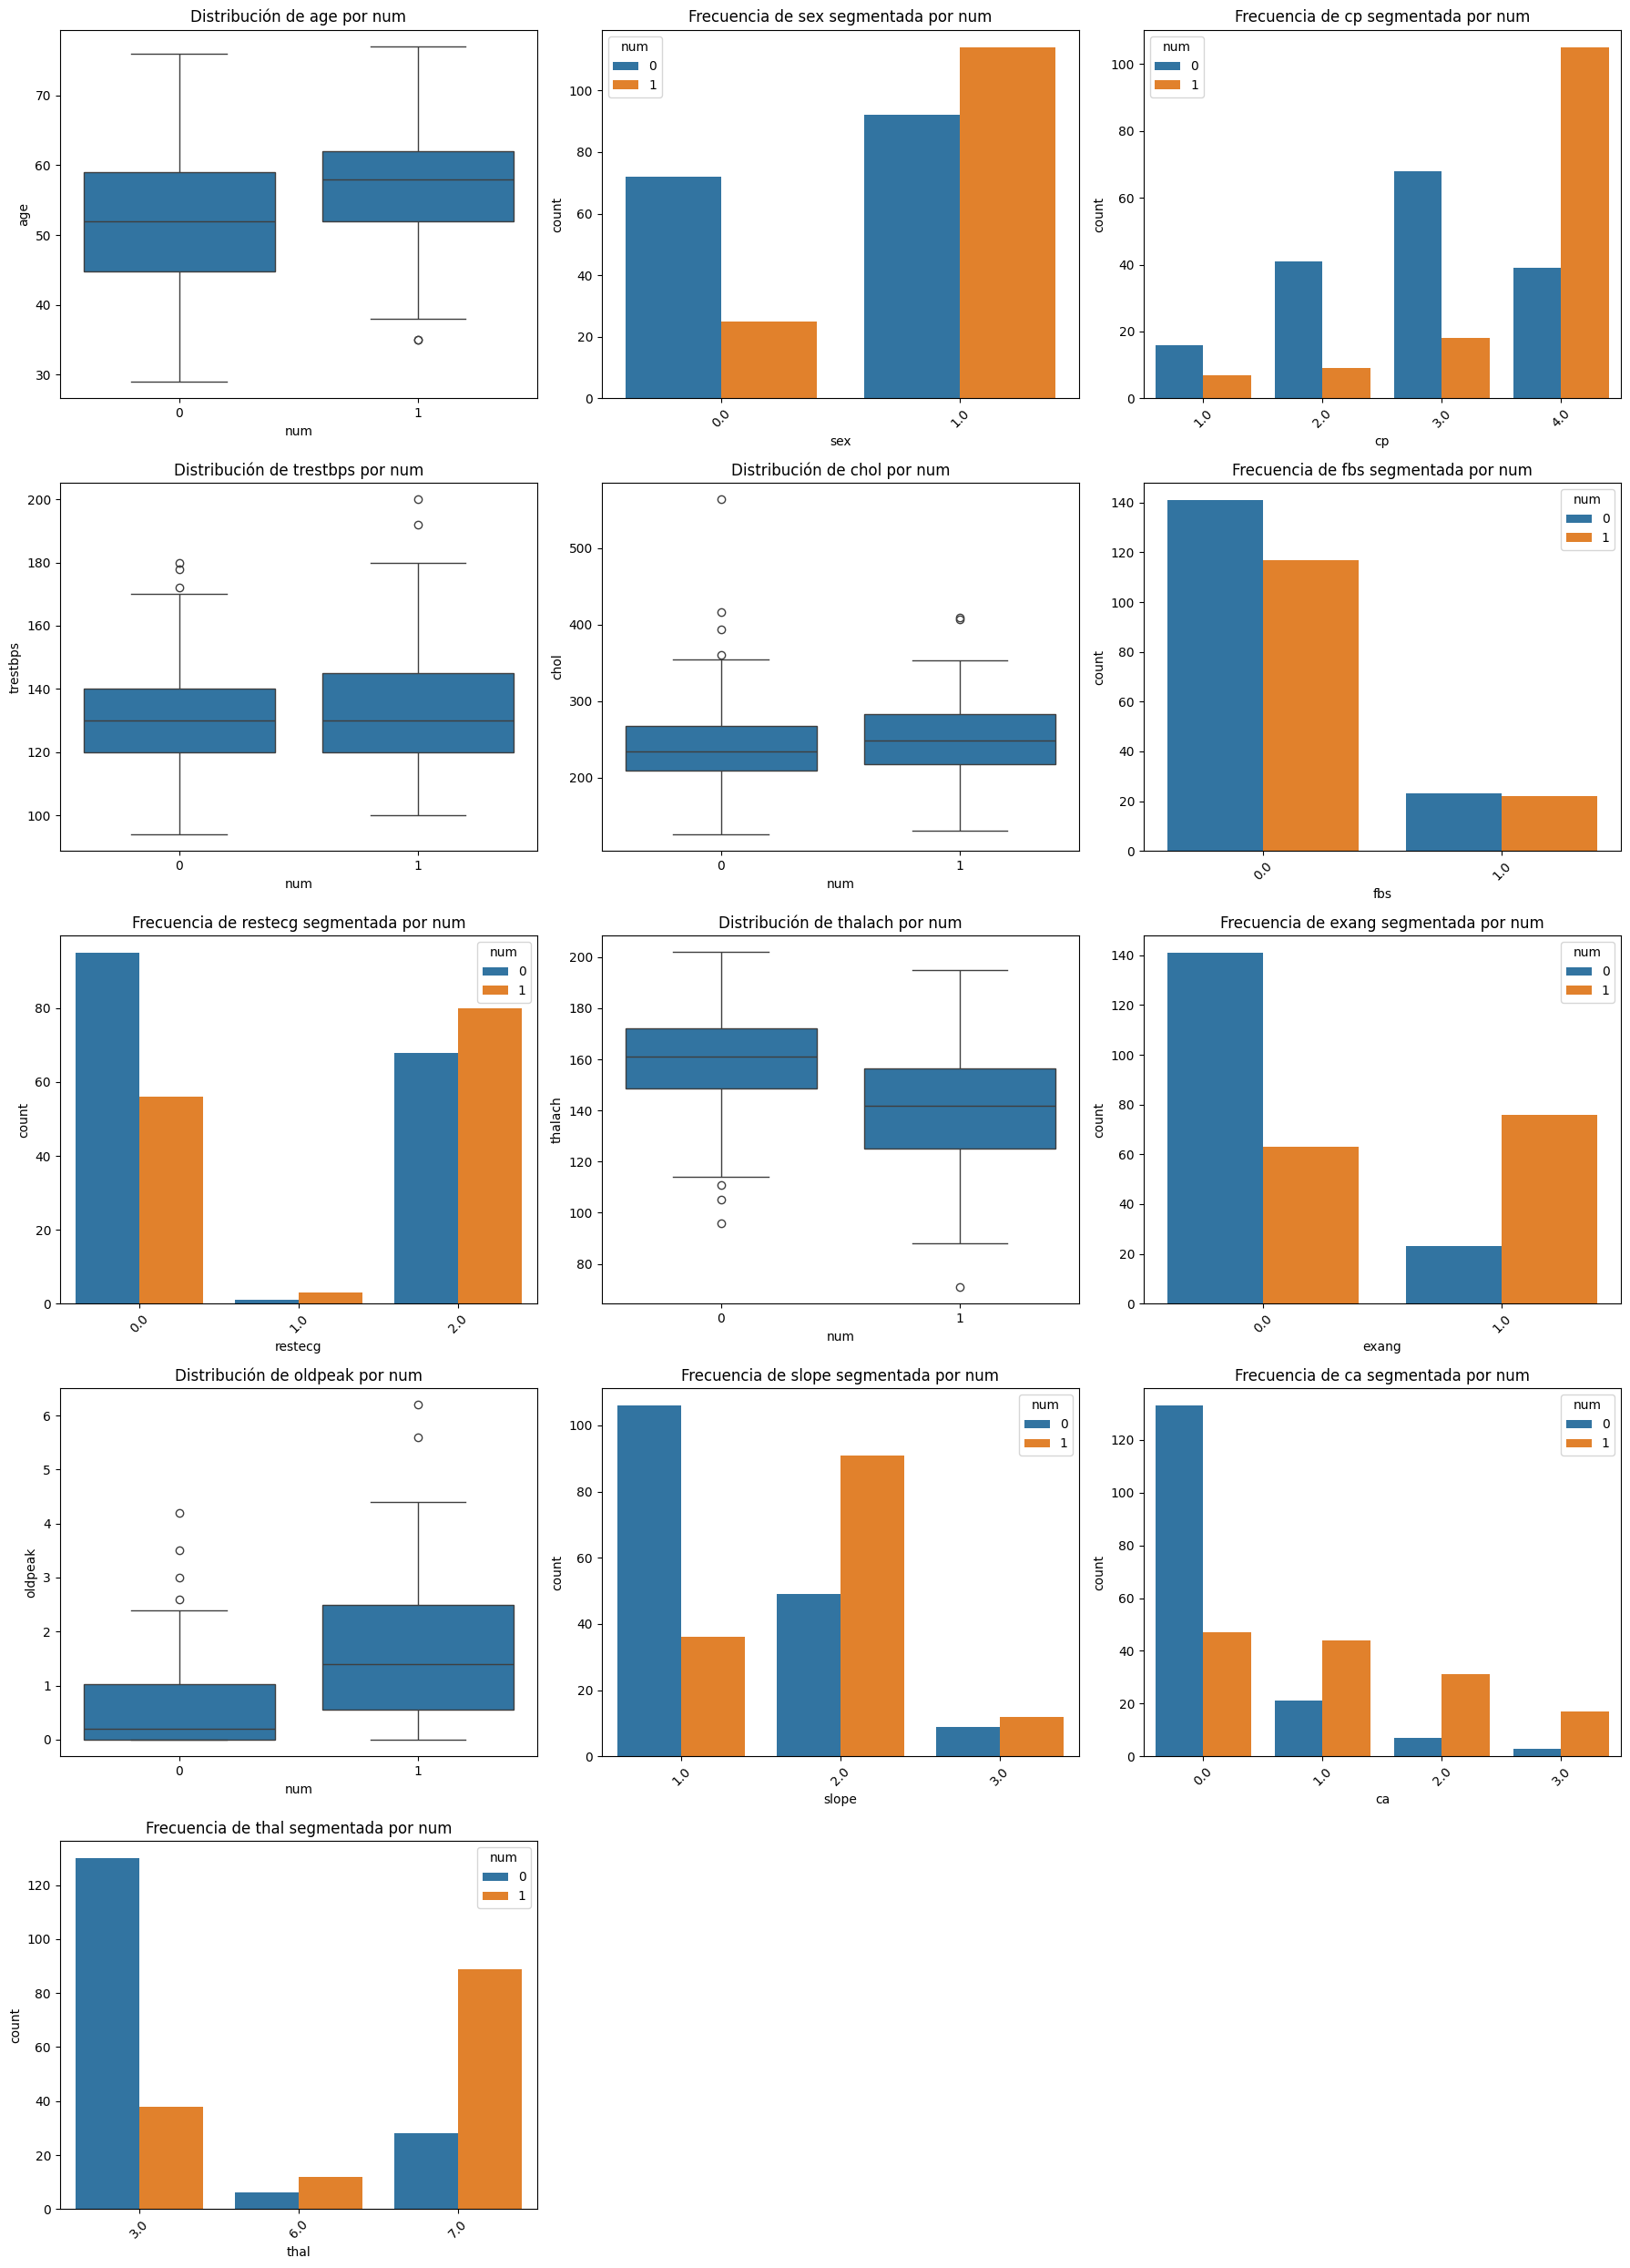

In [46]:
plot_relationships_matrix(df, target_var='num') 

**Edad (``age``):** la distribución es similar en ambos grupos, aunque quienes presentan enfermedad tienden a mostrar una ligera concentración en edades menores comparadas con los sanos.

**Sexo (``sex``):** la mayoría de los casos positivos se concentran en hombres, lo que indica mayor prevalencia en este grupo.

**Tipo de dolor torácico (``cp``):** los pacientes sin enfermedad se asocian más a valores altos de cp (dolor atípico o no anginoso), mientras que los enfermos presentan mayor frecuencia en categorías relacionadas con dolor típico.

**Presión arterial en reposo (``trestbps``) y colesterol (``chol``):** no se observan diferencias marcadas entre enfermos y no enfermos, aunque los valores extremos (outliers) aparecen en ambos grupos.

**Glucemia en ayunas (``fbs``):** la mayoría de los pacientes, enfermos o no, tienen glucemia normal (<120 mg/dl), por lo que esta variable no parece discriminante.

**Electrocardiograma en reposo (``restecg``):** se aprecia una mayor proporción de enfermos con alteraciones en comparación con los sanos.

**Frecuencia cardiaca máxima (``thalach``):** los enfermos tienden a registrar valores más bajos de frecuencia máxima alcanzada, mientras que los sanos muestran distribuciones hacia valores más altos.

**Ejercicio inducido con angina (``exang``):** la mayoría de los casos positivos presentan angina inducida, lo cual marca un patrón diferenciador claro frente a los sanos.

**Depresión del ST inducida (``oldpeak``):** los valores de oldpeak son más altos en los enfermos, lo que refleja un comportamiento esperado en cuadros de isquemia.

**Pendiente del segmento ST (``slope``):** los pacientes sanos se asocian más con pendientes ascendentes (valor 1), mientras que los enfermos predominan en valores descendentes o planos.

**Vasos coloreados por fluoroscopía (``ca``):** los enfermos tienden a concentrarse en valores más altos de esta variable, mientras que los sanos en su mayoría presentan valores bajos (cero vasos afectados).

**Talassemia (``thal``):** se observa que la categoría “normal” se asocia más a los sanos, mientras que las categorías “defecto fijo” y “defecto reversible” presentan mayor proporción en los enfermos.

## ***5. Modelado***

In [47]:
df['num'] = df['num'].astype('int')

In [48]:
X = df.drop(["num"], axis=1)   
y = df["num"]

In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [50]:
num_features = X.select_dtypes(include=["int64", "float64"]).columns
cat_features = X.select_dtypes(include=["object", "category"]).columns

In [51]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

num_transformer = StandardScaler()
cat_transformer = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, num_features),
        ("cat", cat_transformer, cat_features)
    ]
    
)

In [52]:
from sklearn.naive_bayes import GaussianNB

pipe_gaussian = Pipeline(steps=[
("preprocessor", preprocessor),
('nb', GaussianNB())
])

In [53]:
pipe_gaussian.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['age', 'trestbps', 'chol', 'thalach', 'oldpeak'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal'], dtype='object'))])),
                ('nb', GaussianNB())])

## ***6. Evaluación***

### ***6.1 Métricas***

In [54]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import auc, f1_score, precision_score, recall_score, roc_curve


y_pred = pipe_gaussian.predict(X_test)
y_proba = pipe_gaussian.predict_proba(X_test)[:,1]

In [55]:
from sklearn.model_selection import StratifiedKFold, cross_val_score


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipe_gaussian, X, y, cv=cv, scoring="roc_auc")

print("Accuracies CV:", cv_scores)
print("Media accuracy CV:", cv_scores.mean())

Accuracies CV: [0.93939394 0.85822511 0.91774892 0.87654321 0.88727679]
Media accuracy CV: 0.895837592191759


El clasificador Naive Bayes (GaussianNB) alcanzó un accuracy promedio de ~90% bajo validación cruzada estratificada, con variaciones entre 86% y 94%. Esto refleja un buen desempeño general y aceptable estabilidad del modelo. Sin embargo, la dispersión observada sugiere que su rendimiento puede depender en cierta medida de la partición de los datos.

In [56]:
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred))

Matriz de confusión:
[[25 24]
 [ 4 38]]


En la matriz de confusión podemos ver que el modelo tiene dificultad para predecir la clase 0 (sanos), confundiendo casi la mitad de esos casos como clase 1 (enfermo).

In [57]:
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))


Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.86      0.51      0.64        49
           1       0.61      0.90      0.73        42

    accuracy                           0.69        91
   macro avg       0.74      0.71      0.69        91
weighted avg       0.75      0.69      0.68        91



El modelo alcanza una exactitud global del 69%, aunque su desempeño varía entre clases. Para la clase 0 (sanos), presenta buena precisión (0.86) pero bajo recall (0.51), lo que indica que identifica correctamente a la mayoría de los predichos como sanos, pero deja escapar casi la mitad de los casos reales. En contraste, para la clase 1 (enfermos), el recall es muy alto (0.90), lo que significa que detecta casi todos los enfermos, aunque con una precisión más baja (0.61), generando varios falsos positivos. En conjunto, los valores F1 muestran un rendimiento moderado y más equilibrado en la clase 1 (0.73) que en la clase 0 (0.64), reflejando que el modelo prioriza la detección de la enfermedad a costa de clasificar erróneamente a algunos individuos sanos.

In [58]:
# Calcular métricas
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Crear DataFrame
metrics_df = pd.DataFrame({
    'Accuracy': [accuracy],
    'Precision': [precision],
    'Recall': [recall],
    'F1-score': [f1]
})

print(metrics_df)

   Accuracy  Precision    Recall  F1-score
0  0.692308   0.747069  0.692308  0.682446


El modelo evidencia un desempeño moderado, con una exactitud del 69%. La precisión alcanza un 75%, lo que indica que, al predecir la presencia de enfermedad, el modelo acierta en tres de cada cuatro casos. Sin embargo, el recall del 69% revela que no logra identificar a todos los individuos enfermos, generando falsos negativos. El F1-score de 68% refleja este balance intermedio, sugiriendo que el clasificador prioriza la precisión por encima de la sensibilidad, aspecto relevante a considerar en aplicaciones médicas.

### ***6.2. Gráficos***

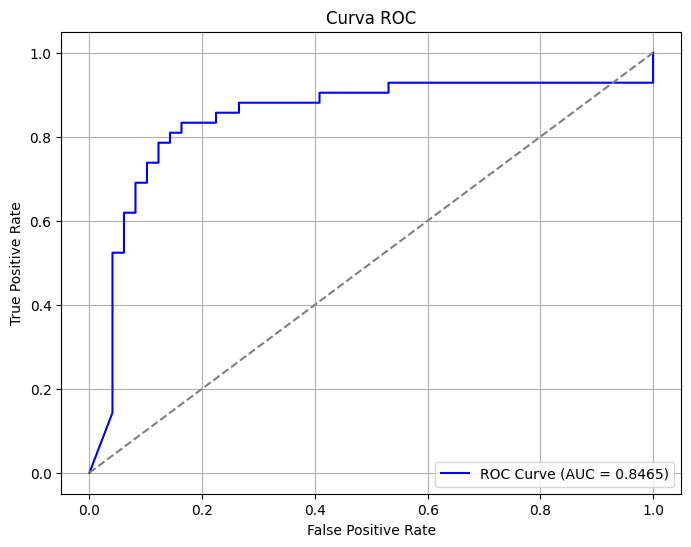

In [59]:
from sklearn.metrics import roc_auc_score


y_proba = pipe_gaussian.predict_proba(X_test)[:, 1] 

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# Calcular AUC
auc_score = roc_auc_score(y_test, y_proba)

# Graficar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc_score:.4f})", color='blue')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray') 
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend(loc="lower right")
plt.grid()
plt.show()

El AUC de 0.8465 indica que el modelo tiene una buena capacidad para discriminar entre pacientes enfermos y sanos. Esto sugiere que, si se toma un paciente enfermo y uno sano al azar, hay un 84.65% de probabilidad de que el modelo asigne una puntuación más alta al paciente enfermo. Esta métrica confirma que, a pesar de no alcanzar una sensibilidad perfecta, el modelo maneja razonablemente bien el compromiso entre falsos positivos y falsos negativos.

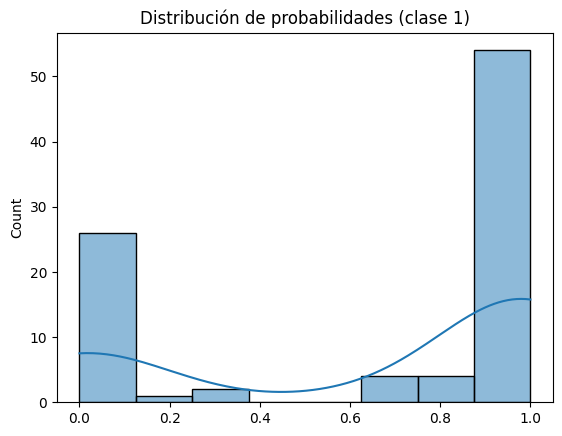

In [60]:
# Distribución de probabilidades predichas
sns.histplot(y_proba, kde=True)
plt.title('Distribución de probabilidades (clase 1)')
plt.show()


La distribución de probabilidades para la clase 1 muestra una clara separación entre las clases, con la mayoría de las predicciones agrupadas en torno a 0 (sanos) y 1 (enfermos). Esta distribución bimodal indica que el modelo toma decisiones con alta confianza y tiene buena capacidad de discriminación. La escasa cantidad de observaciones con probabilidades intermedias sugiere que el modelo raramente se encuentra indeciso.

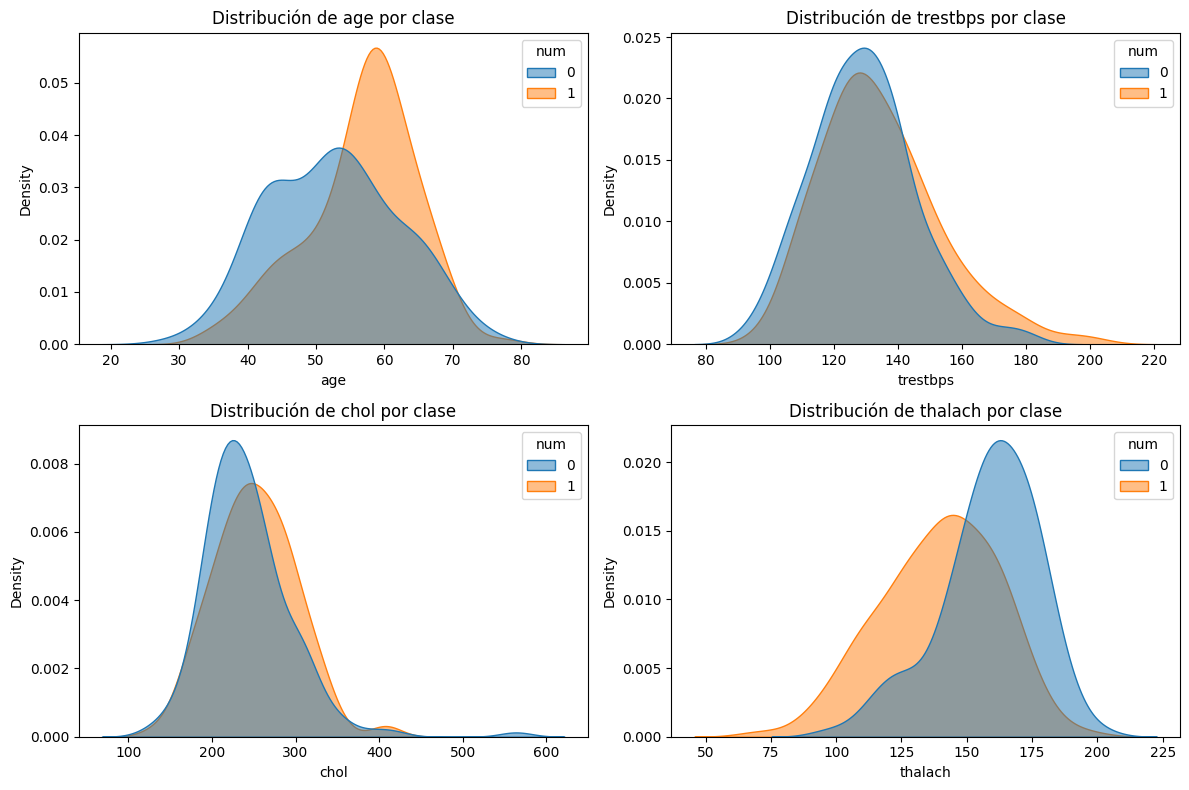

In [61]:
cols = ["age", "trestbps", "chol", "thalach"]

# Crear figura y ejes
fig, axes = plt.subplots(2, 2, figsize=(12, 8)) 


axes = axes.flatten()

for i, col in enumerate(cols):
    sns.kdeplot(
        x=X[col], 
        hue=y, 
        fill=True, 
        common_norm=False, 
        alpha=0.5,
        ax=axes[i]
    )
    axes[i].set_title(f"Distribución de {col} por clase")

plt.tight_layout()
plt.show()



**`age`:** Podemos observar cómo la clase 1 tiene una mayor concentración de pacientes en el rango de 55 a 65 años, mientras que la clase 0 muestra una distribución más amplia, con un pequeño pico entre los 40 y 50 años. Por tanto, la edad más avanzada se asocia con mayor probabilidad de enfermedad, por lo que el modelo podría usar la edad como un predictor útil, especialmente en los extremos.

**`trestbps`:** Encontramos que las distribuciones se superponen bastante, aunque los pacientes enfermos (clase 1) tienden a tener valores ligeramente más altos. Esto es observable en la cola más larga hacia la derecha, lo cual indica presiones más altas para los enfermos. Aunque hay una diferencia sutil entre las clases, no es suficiente para considerar esta variable fuertemente discriminativa por sí sola, por lo que podría ser más útil en combinación con otras variables.

**`chol`:** Ambas clases presentan valores similares dentro del rango 180–280. Sin embargo, los enfermos muestran una mayor dispersión hacia valores más altos (cola a la derecha). En conclusión, el colesterol parece ser útil cuando los valores son muy altos, pero en general, las clases están bastante mezcladas, por lo que podría tener utilidad predictiva cuando se superen ciertos umbrales.

**`thalach`:** Es una variable más diferenciable, pues podemos ver cómo la clase 0 alcanza valores de frecuencia cardíaca más altos (un pico en torno a 170), mientras que los enfermos (clase 1) tienen picos más bajos, alrededor de 140–150. Esta, por tanto, es una variable altamente discriminativa, ya que indica que los pacientes sanos tienden a alcanzar frecuencias cardíacas máximas más altas.

C:\Users\maria\AppData\Local\Temp\ipykernel_22932\3393448982.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_test, ax=ax[0], palette="Set2")
C:\Users\maria\AppData\Local\Temp\ipykernel_22932\3393448982.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_pred, ax=ax[1], palette="Set1")


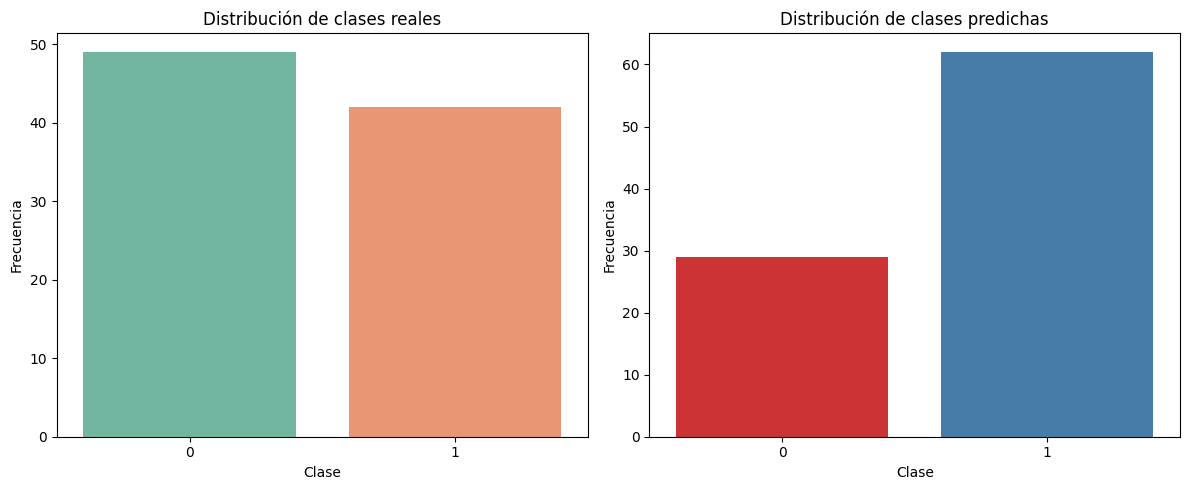

In [62]:
# Predicciones del modelo entrenado
y_pred = pipe_gaussian.predict(X_test)

# Gráfico de barras de las clases reales vs predichas
fig, ax = plt.subplots(1,2, figsize=(12,5))

sns.countplot(x=y_test, ax=ax[0], palette="Set2")
ax[0].set_title("Distribución de clases reales")
ax[0].set_xlabel("Clase")
ax[0].set_ylabel("Frecuencia")

sns.countplot(x=y_pred, ax=ax[1], palette="Set1")
ax[1].set_title("Distribución de clases predichas")
ax[1].set_xlabel("Clase")
ax[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

El modelo tiende a predecir una mayor proporción de casos como positivos (clase 1) en comparación con la distribución real de las clases. Mientras que las clases reales están razonablemente balanceadas, el clasificador predice más casos positivos de los que realmente hay. Este sesgo hacia la clase positiva puede indicar un intento del modelo por minimizar falsos negativos, una estrategia que puede ser adecuada en contextos clínicos, donde es preferible detectar a más pacientes potencialmente enfermos, aunque implique un mayor número de falsos positivos.

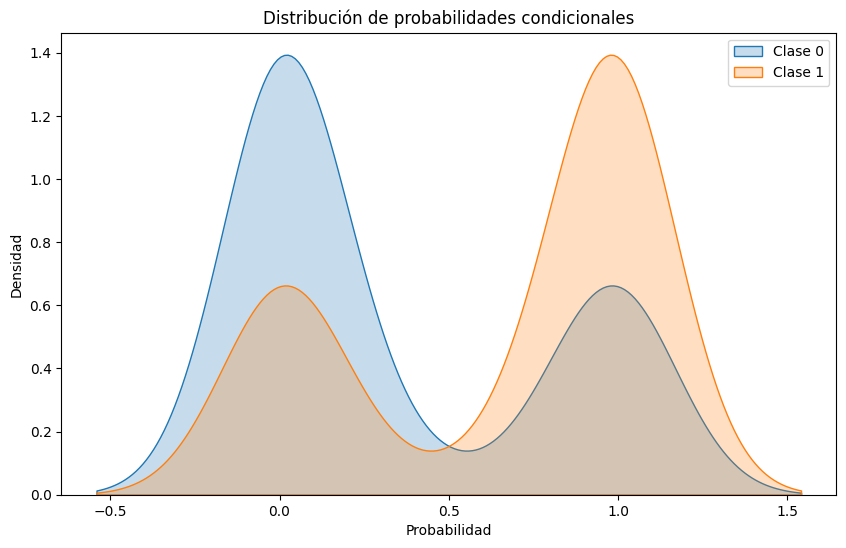

In [63]:
# Obtener probabilidades de predicción
y_proba = pipe_gaussian.predict_proba(X_test)

# Crear un DataFrame con las probabilidades
import pandas as pd
proba_df = pd.DataFrame(y_proba, columns=[f"Clase {c}" for c in pipe_gaussian.classes_])

# Histograma / KDE de las probabilidades
plt.figure(figsize=(10,6))
for col in proba_df.columns:
    sns.kdeplot(proba_df[col], fill=True, label=col)

plt.title("Distribución de probabilidades condicionales")
plt.xlabel("Probabilidad")
plt.ylabel("Densidad")
plt.legend()
plt.show()


El modelo muestra una buena capacidad para separar ambas clases en términos de probabilidad: asigna valores cercanos a 0 para la clase 0 y valores cercanos a 1 para la clase 1. Aunque existe cierta zona de solapamiento donde las predicciones podrían ser inciertas, la mayoría de los casos son bien diferenciados. Esto sugiere que el modelo tiene un buen poder discriminativo.

### ***6.3. Comparación con el modelo logístico***

Se crea un pipeline para aplicar regresión logística, el cual primero pasa los datos por un preprocesador y luego ajusta el modelo de regresión logística. 

In [64]:
pipe_log = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("lr", LogisticRegression(max_iter=1000))
])

Aquí el modelo que se define con el pipeline y se entrena con los datos de entrenamiento (`X_train` y `y_train`). 

In [65]:
pipe_log.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['age', 'trestbps', 'chol', 'thalach', 'oldpeak'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal'], dtype='object'))])),
                ('lr', LogisticRegression(max_iter=1000))])

Una vez entrenado el modelo, se hacen las predicciones sobre los datos de prueba (`X_test`). Primero se genera la predicción de clase (`y_pred`) y luego se calculan las probabilidades (`y_proba`) que el modelo asigna a cada clase.

In [66]:
y_pred = pipe_log.predict(X_test)
y_proba = pipe_log.predict_proba(X_test)

Para evaluar el rendimiento del modelo de manera más robusta, se hace validación cruzada con 5 particiones, manteniendo balanceadas las clases gracias a `StratifiedKFold`. Luego se usa `cross_val_score` para calcular la métrica `roc_auc` en cada uno de los folds. Al final se imprimen los scores individuales de cada fold y también el promedio.

In [67]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipe_log, X, y, cv=cv, scoring="roc_auc")

print("Accuracies CV:", cv_scores)
print("Media accuracy CV:", cv_scores.mean())

Accuracies CV: [0.95670996 0.8982684  0.90692641 0.90796857 0.92410714]
Media accuracy CV: 0.9187960958794292


Los resultados de la validación cruzada muestran que el modelo tiene un rendimiento bastante sólido al clasificar los datos, con puntuaciones de AUC-ROC que van desde aproximadamente 0.89 hasta 0.95, y una media cercana a 0.92. Esto indica que el modelo tiene buena capacidad para diferenciar entre las dos clases.

In [68]:
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

Matriz de confusión:
[[43  6]
 [ 7 35]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.86      0.88      0.87        49
           1       0.85      0.83      0.84        42

    accuracy                           0.86        91
   macro avg       0.86      0.86      0.86        91
weighted avg       0.86      0.86      0.86        91



En cuanto al desempeño sobre el conjunto de prueba, la matriz de confusión revela que el modelo clasificó correctamente 43 casos de la clase 0 y 35 de la clase 1. Sin embargo, también se cometieron algunos errores: 6 veces se predijo clase 1 cuando era 0 (falsos positivos) y 7 veces se predijo clase 0 cuando era 1 (falsos negativos). A pesar de eso, las métricas generales siguen siendo bastante buenas.

El reporte de clasificación muestra que para la clase 0 se logró una precisión de 0.86 y un recall de 0.88, mientras que para la clase 1 la precisión fue de 0.85 y el recall de 0.83. Estos valores reflejan un equilibrio entre la capacidad del modelo para detectar correctamente los positivos y no etiquetar erróneamente los negativos. El F1-score promedio ponderado es 0.86, lo que confirma un buen balance entre precisión y recall.

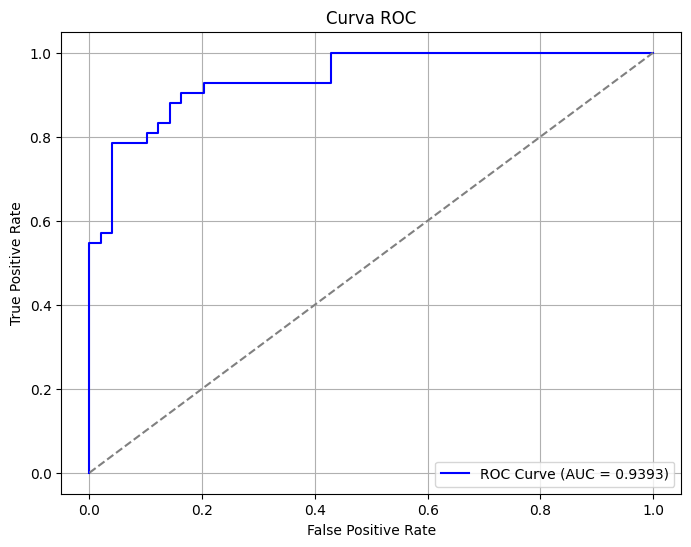

In [69]:
from sklearn.metrics import roc_auc_score


y_proba = pipe_log.predict_proba(X_test)[:, 1] 

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# Calcular AUC
auc_score = roc_auc_score(y_test, y_proba)

# Graficar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc_score:.4f})", color='blue')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray') 
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend(loc="lower right")
plt.grid()
plt.show()

La curva ROC que se muestra evalúa qué tan bien el modelo logra distinguir entre las clases positivas y negativas a través de distintos umbrales de decisión. En el gráfico, se puede observar que la curva se acerca bastante al vértice superior izquierdo, lo cual indica un muy buen rendimiento. Además, el área bajo la curva (AUC) es de aproximadamente 0.9393, lo que significa que el modelo tiene una excelente capacidad de discriminación. En términos simples, cuanto más alto es el AUC, mejor es el modelo para separar correctamente las clases, y en este caso ese valor tan cercano a 1 refleja un comportamiento bastante sólido. También se nota que el modelo mantiene una tasa de verdaderos positivos alta incluso cuando la tasa de falsos positivos es baja, lo cual es una señal muy positiva para tareas de clasificación binaria.


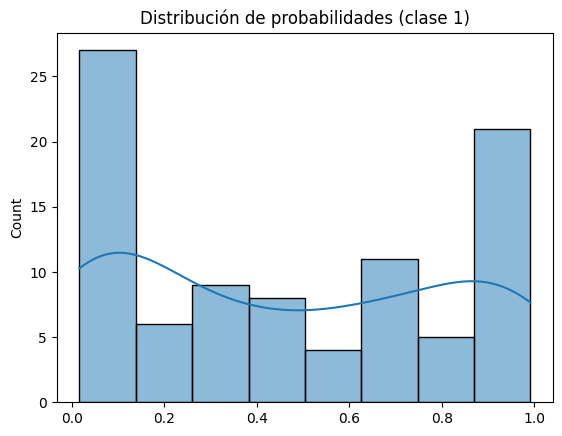

In [70]:
# Distribución de probabilidades predichas
sns.histplot(y_proba, kde=True)
plt.title('Distribución de probabilidades (clase 1)')
plt.show()

En la gráfica resultante se observa que las probabilidades tienden a agruparse cerca de los extremos (0 y 1), con una clara mayor frecuencia en la zona baja, lo que indica que el modelo clasifica a la mayoría de los casos como clase 0, pero también hay un número importante de casos que recibe una probabilidad alta de ser clase 1. Esto sugiere que el modelo toma decisiones con cierto nivel de confianza en muchos casos, ya que no hay una gran acumulación en valores intermedios donde el modelo suele “dudar”. Además, la forma de la curva refuerza la idea de que el modelo diferencia relativamente bien entre ambas clases.

C:\Users\maria\AppData\Local\Temp\ipykernel_22932\2537787925.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_test, ax=ax[0], palette="Set2")
C:\Users\maria\AppData\Local\Temp\ipykernel_22932\2537787925.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_pred, ax=ax[1], palette="Set1")


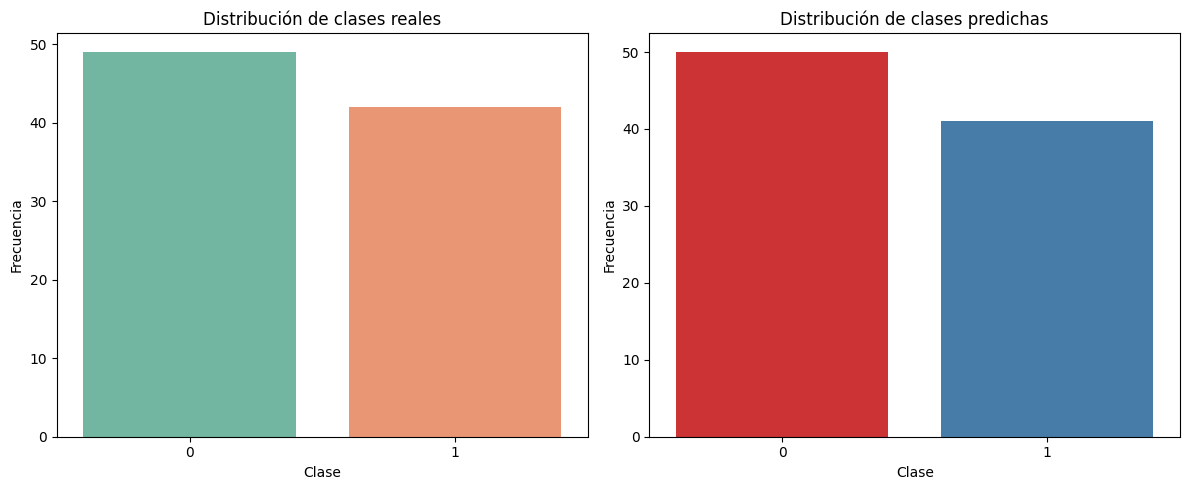

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

# Predicciones del modelo entrenado
y_pred = pipe_log.predict(X_test)

# Gráfico de barras de las clases reales vs predichas
fig, ax = plt.subplots(1,2, figsize=(12,5))

sns.countplot(x=y_test, ax=ax[0], palette="Set2")
ax[0].set_title("Distribución de clases reales")
ax[0].set_xlabel("Clase")
ax[0].set_ylabel("Frecuencia")

sns.countplot(x=y_pred, ax=ax[1], palette="Set1")
ax[1].set_title("Distribución de clases predichas")
ax[1].set_xlabel("Clase")
ax[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()


Al observar las gráficas, note que la distribución de clases reales y la de las clases predichas son bastante similares, lo que sugiere que el modelo no está sesgado hacia una clase en particular y está capturando bien la proporción de casos. 

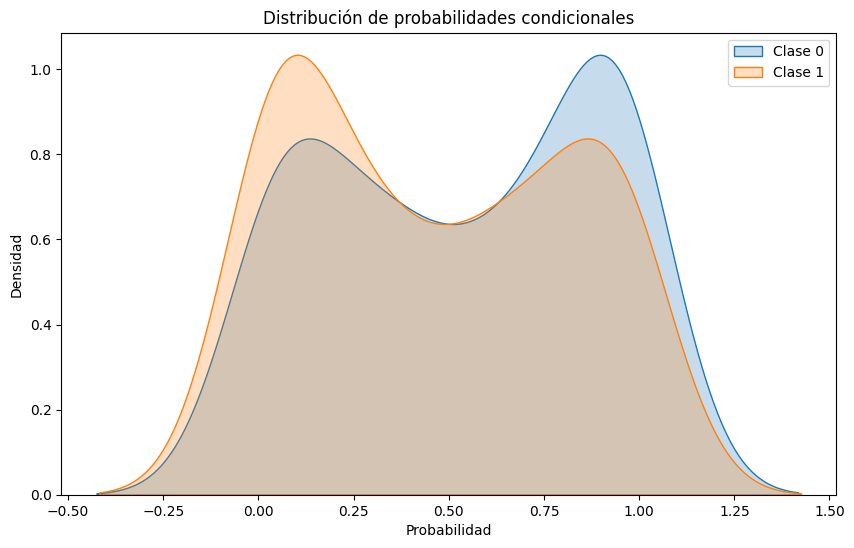

In [72]:
# Obtener probabilidades de predicción
y_proba = pipe_log.predict_proba(X_test)

# Crear un DataFrame con las probabilidades
import pandas as pd
proba_df = pd.DataFrame(y_proba, columns=[f"Clase {c}" for c in pipe_log.classes_])

# Histograma / KDE de las probabilidades
plt.figure(figsize=(10,6))
for col in proba_df.columns:
    sns.kdeplot(proba_df[col], fill=True, label=col)

plt.title("Distribución de probabilidades condicionales")
plt.xlabel("Probabilidad")
plt.ylabel("Densidad")
plt.legend()
plt.show()

La gráfica muestra la distribución de las probabilidades predichas para cada clase, usando un gráfico KDE (estimación de densidad). Note que las distribuciones están bastante separadas, lo que indica que el modelo tiene una buena capacidad para discriminar entre las clases 0 y 1, asignando probabilidades altas a la clase correcta en la mayoría de los casos. Sin embargo, hay una superposición en el medio, lo que refleja incertidumbre en ciertos casos.

#### ***Comparación entre GaussianNB y Regresión Logística***

De acuerdo con las métricas y gráficas anteriores, los dos modelos sirven para predecir la presencia o ausencia de enfermedad cardíaca, pero muestran diferencias importantes:

- **Precisión y exactitud:**  
  La **Regresión Logística** logra un mejor resultado en estas métricas. Esto significa que se equivoca menos al clasificar a los pacientes. En un contexto médico esto es muy útil, porque evita confundir a una persona sana con alguien enfermo o viceversa. GaussianNB, en cambio, comete más errores debido a que parte de un supuesto más simplificado de los datos.

- **Curva ROC y AUC:**  
  El valor de AUC es más alto en la **Regresión Logística**, lo que muestra que distingue mejor entre pacientes con y sin la enfermedad. En medicina esto importa porque ayuda a priorizar a los pacientes en riesgo real, mientras que GaussianNB no logra separar tan claramente a ambos grupos.

- **Interpretación y simplicidad:**  
  Aunque GaussianNB no alcanza la misma precisión, sí es más fácil de entender. Sus resultados se basan en probabilidades directas de cada variable clínica (como colesterol o presión), lo que puede dar pistas rápidas a los médicos sobre qué factor está influyendo más. La Regresión Logística es más exacta, pero sus resultados no siempre se interpretan de manera tan inmediata.

- **Visualizaciones:**  
  Las gráficas muestran que la **Regresión Logística** se ajusta mejor a los datos, mientras que GaussianNB genera límites más simples. Esto explica por qué la primera acierta más, pero también por qué la segunda es más ligera y rápida de aplicar.

Por lo tanto, en la predicción de enfermedades cardíacas:  
- **Regresión Logística** es más confiable porque se equivoca menos y separa mejor a los pacientes sanos de los enfermos.  
- **GaussianNB** es menos preciso, pero más sencillo y fácil de interpretar, lo que lo hace útil como apoyo para entender qué variables influyen en el riesgo de la enfermedad.


## **7. Análisis y reporte final**

### **7.1. Relevancia de Variables:**

In [73]:
nb_model = pipe_gaussian.named_steps['nb']

theta = nb_model.theta_
var = nb_model.var_

# Diferencia absoluta entre medias clase 0 y 1
mean_diff = np.abs(theta[0] - theta[1])

# Recuperar nombres de features después del preprocesamiento
ohe = pipe_gaussian.named_steps['preprocessor'].named_transformers_['cat']
cat_names = ohe.get_feature_names_out(cat_features)
all_features = list(num_features) + list(cat_names)

# Construir ranking
relevance = pd.DataFrame({
    "feature": all_features,
    "mean_diff": mean_diff
}).sort_values(by="mean_diff", ascending=False)

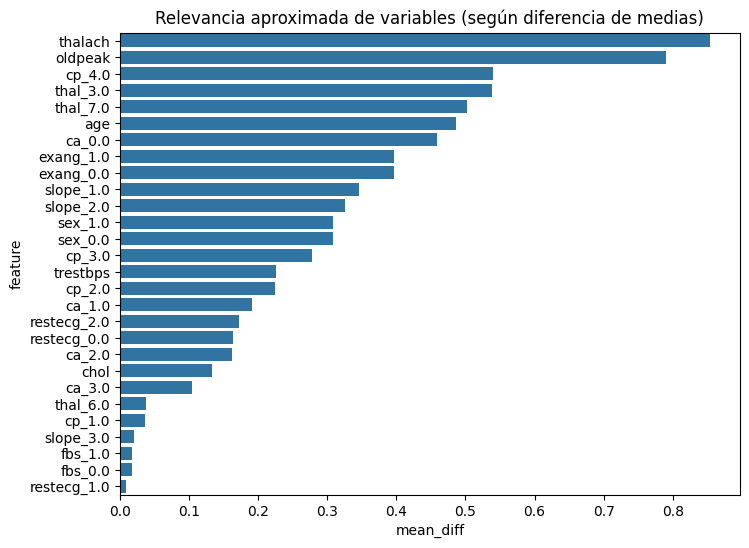

In [74]:
plt.figure(figsize=(8,6))
sns.barplot(data=relevance, x="mean_diff", y="feature")
plt.title("Relevancia aproximada de variables (según diferencia de medias)")
plt.show()

La gráfica nos muestra la relevancia aproximada de las variables según la diferencia de medias, esto significa que aquellas variables con gran separación entre grupos aportan más información para discriminar, mientras que aquellas con valores pequeños o cercanos a cero apenas modifican la probabilidad y, por tanto, no se consideran relevantes. En nuestro gráfico observamos cómo las variables con mayor relevancia son ``thalach`` y ``oldpeak``, seguidas por algunas categorías específicas de variables como ``cp_4.0``, ``thal_3.0``, ``thal_7.0`` y ``la edad``, que también muestran diferencias marcadas entre clases. En contraste, las variables con menor relevancia son ``fbs_0``, ``fbs_1.0`` y ``restecg_1.0``, ya que su contribución es mínima en la separación de grupos y, por ende, apenas influyen en la estimación de probabilidades.

### **7.2. Fortalezas y Limitaciones del Modelo:**

El modelo de clasificación implementado mediante Bayes presenta como principales fortalezas su simplicidad, rapidez de entrenamiento e interpretabilidad, lo cual permitió identificar con claridad variables de alta relevancia, como thalach y oldpeak. Además, su capacidad de manejar datos categóricos de manera eficiente favorece su adaptación al conjunto analizado. No obstante, el modelo también evidencia limitaciones asociadas a la asunción de independencia entre variables y a la suposición de normalidad en las distribuciones continuas, condiciones que no siempre se cumplen en los datos médicos. Asimismo, su sensibilidad a valores atípicos y la menor precisión en comparación con modelos más complejos restringen su aplicabilidad en contextos donde se requiere un alto nivel de exactitud predictiva.

En general, al compararlo con el modelo logístico podemos ver que cada modelo cuenta con las siguientes fortalezas y limitaciones:

| Modelo              | Fortalezas                                                                 | Limitaciones                                                                 |
|---------------------|-----------------------------------------------------------------------------|------------------------------------------------------------------------------|
| **GaussianNB**      | - Muy rápido y simple de aplicar.<br>- Ofrece predicciones probabilísticas fáciles de interpretar.<br>- Útil para ver cómo cada variable clínica influye en el riesgo. | - Supone que los datos siguen una distribución normal, lo que no siempre se cumple.<br>- Menor precisión en comparación con otros modelos.<br>- Simplifica demasiado las relaciones entre variables. |
| **Regresión Logística** | - Mayor precisión y exactitud en las métricas.<br>- Buena capacidad para separar pacientes sanos y enfermos.<br>- Resultados confiables y usados con frecuencia en medicina. | - Puede ser menos intuitiva de interpretar para personas sin formación técnica.<br>- Más sensible a datos desbalanceados.<br>- Requiere un preprocesamiento de datos más cuidadoso. |



### **7.3. Reflexión sobre Interpretabilidad y Aplicabilidad Médica:**

La interpretabilidad del modelo de Bayes constituye una ventaja significativa en el ámbito médico, dado que permite comprender de manera transparente cómo cada variable influye en la probabilidad de presencia o ausencia de enfermedad. Este aspecto es clave en contextos clínicos, donde no solo se busca una predicción precisa, sino también la posibilidad de justificar las decisiones ante profesionales de la salud y pacientes. Sin embargo, su aplicabilidad práctica debe ser analizada con cautela: si bien ofrece una herramienta rápida para apoyar el diagnóstico inicial y resaltar factores de riesgo relevantes, las limitaciones derivadas de la asunción de independencia y de la simplificación de las distribuciones estadísticas hacen necesario complementarlo con otros modelos más robustos o con criterios clínicos especializados. En este sentido, el Naive Bayes resulta útil como apoyo exploratorio y orientador, más que como una herramienta definitiva de diagnóstico médico.

Por otra parte, al compararlo con el modelo de regresión logística tenemos que:

| Modelo              | Fortalezas en medicina                                                                 | Limitaciones en medicina                                                                 |
|---------------------|----------------------------------------------------------------------------------------|------------------------------------------------------------------------------------------|
| **GaussianNB**      | - Fácil de interpretar para médicos porque entrega probabilidades claras.<br>- Permite identificar rápidamente qué variables clínicas influyen más en el riesgo (ejemplo: colesterol o presión).<br>- Rápido y práctico para sistemas de salud con recursos limitados. | - Puede perder precisión si los datos clínicos no se ajustan a una distribución normal.<br>- Riesgo de clasificar mal a algunos pacientes, lo que en medicina significa falsos positivos o falsos negativos. |
| **Regresión Logística** | - Ofrece mayor precisión y confiabilidad en el diagnóstico.<br>- Distingue mejor entre pacientes sanos y enfermos, lo que ayuda a priorizar la atención médica.<br>- Es un modelo aceptado y usado con frecuencia en estudios clínicos. | - Puede ser más difícil de entender para profesionales de la salud sin formación en estadística.<br>- Necesita datos bien preparados para mantener su buen rendimiento.<br>- Puede verse afectado si los datos están desbalanceados. |
